In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
%matplotlib inline 

In [2]:
df = pd.read_csv("Datasets/home.csv", index_col=0)

In [3]:
df.head(5)

,area,building_floors,district,flat_floor,neighborhood,price,rooms_count,warming_type
0,80,16,Beylikdüzü,14,Cumhuriyet,349000,2.0,Kombi
1,115,9,Kadıköy,6,Kozyatağı,1325000,4.0,Kombi
2,405,3,Beylikdüzü,3,Adnan Kahveci,4900000,9.0,Kombi
3,100,7,Esenyurt,-1,Cumhuriyet,169999,3.0,Kombi
4,150,5,Beşiktaş,1,Bebek,11000000,4.0,Merkezi


In [4]:
district = df.district[:250]

In [5]:
value_district = pd.DataFrame(district.value_counts())

In [6]:
value_district

,district
Kadıköy,60
Beylikdüzü,50
Esenyurt,30
Maltepe,24
Beşiktaş,22
Başakşehir,10
Avcılar,7
Ataşehir,7
Kağıthane,6
Şişli,6


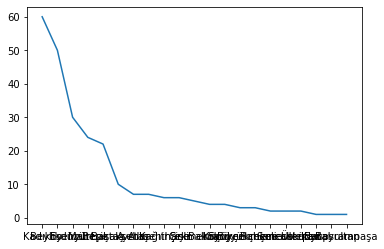

In [7]:
plt.plot(value_district);

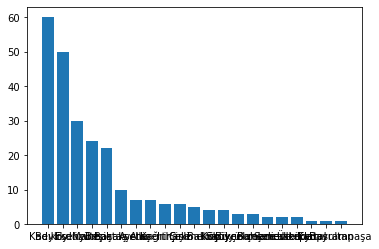

In [8]:
plt.bar(value_district.index, value_district.district);

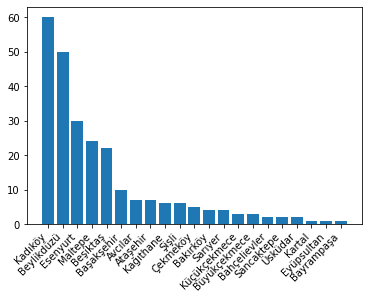

In [9]:
plt.bar(value_district.index, value_district.district)
plt.xticks(rotation=45, ha='right');

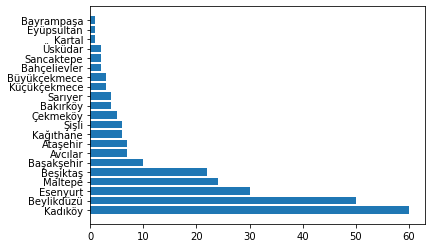

In [10]:
plt.barh(value_district.index, value_district.district);

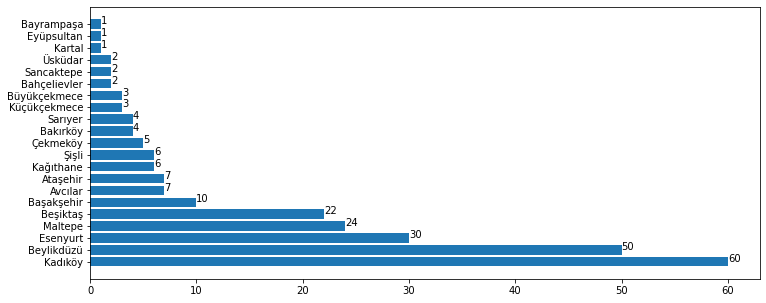

In [11]:
plt.figure(figsize=[12,5])
plt.barh(value_district.index, value_district.district)
for index, value in enumerate(value_district.district):
    plt.text(value, index, str(value))

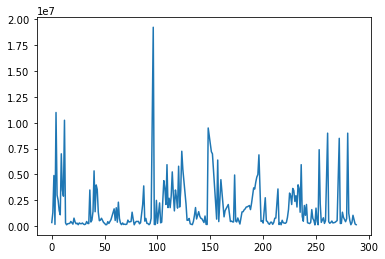

In [12]:
data_list_price = df.price[:250]
plt.plot(data_list_price);

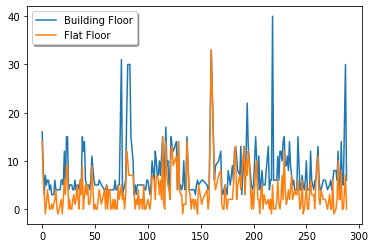

In [13]:
data_list_building = df.building_floors[:250]
data_list_flat = df.flat_floor[:250]
plt.plot(data_list_building)
plt.plot(data_list_flat)
plt.legend(['Building Floor','Flat Floor'], shadow=True);

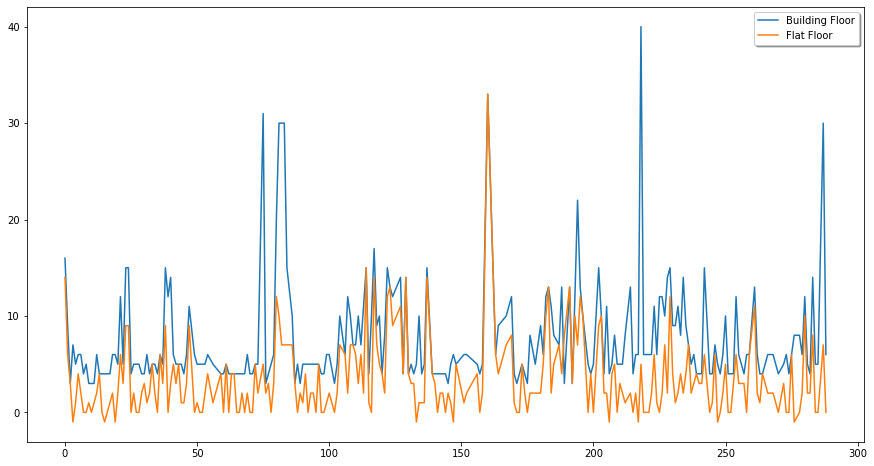

In [14]:
plt.figure(figsize=[15,8])
data_list_building = df.building_floors[:250]
data_list_flat = df.flat_floor[:250]
plt.plot(data_list_building)
plt.plot(data_list_flat)
plt.legend(['Building Floor','Flat Floor'], shadow=True);

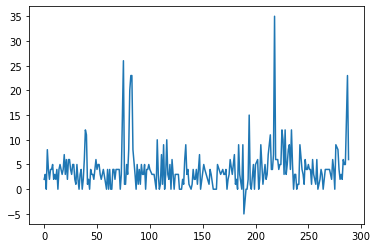

In [15]:
floor_number = data_list_building - data_list_flat
plt.plot(floor_number);

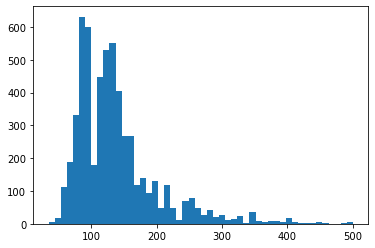

In [16]:
plt.hist(df.area, bins=50);

In [17]:
district_price = pd.DataFrame(df.groupby("district")["price"].mean().sort_values(ascending=False))
district_price.head(10)

,price
district,
Beşiktaş,4.966661e+06
Sarıyer,4.179442e+06
Beykoz,4.111200e+06
Bakırköy,3.934192e+06
Kadıköy,2.713153e+06
Adalar,1.898167e+06
Beyoğlu,1.892855e+06
Eyüpsultan,1.449506e+06
Şişli,1.383376e+06


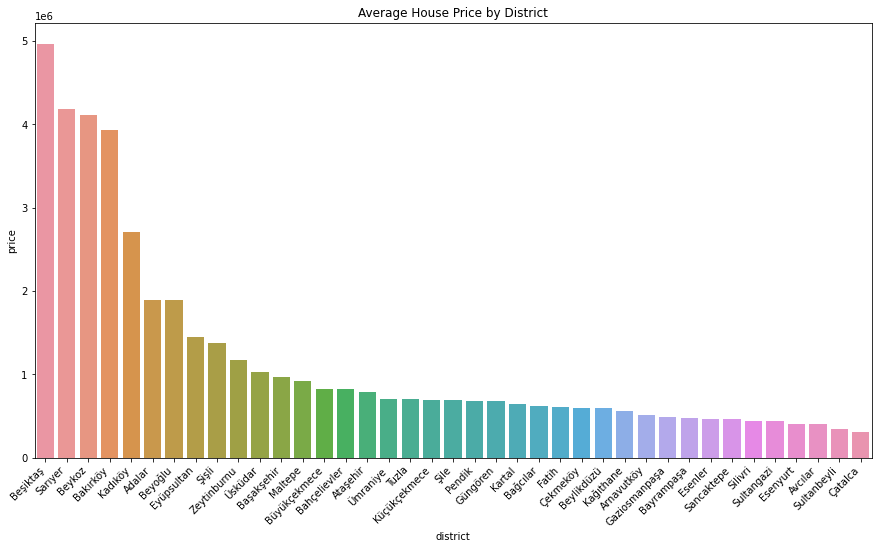

In [18]:
plt.figure(figsize=[15,8])
sns.barplot(x=district_price.index, y=district_price.price, data=district_price)
plt.xticks(rotation=45, ha='right')
plt.title("Average House Price by District");

In [19]:
value_warming = pd.DataFrame(df.warming_type.value_counts())
value_warming

,warming_type
Kombi,4487
Merkezi,610
Merkezi (Pay Ölçer),537
Rare,84


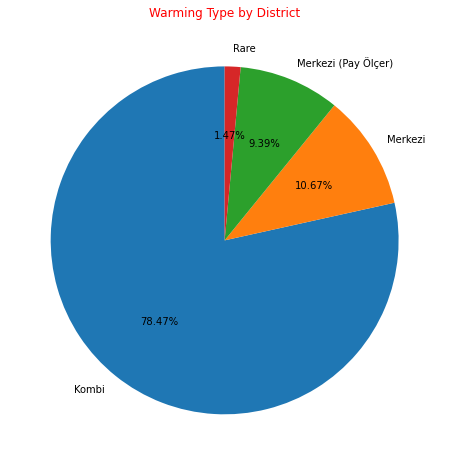

In [20]:
plt.figure(figsize=[15,8])
plt.pie(value_warming.warming_type, labels=value_warming.index, autopct='%1.2f%%', startangle=90)
plt.title("Warming Type by District", color="red");

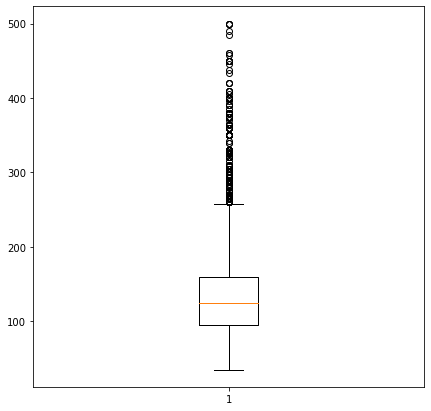

In [21]:
plt.figure(figsize =[7,7])
plt.boxplot(df.area);

In [22]:
def extract_whiskers(data):
    median_value = np.median(data) # Medyan
    upper_quartile = np.percentile(data, 75) # 75%
    lower_quartile = np.percentile(data, 25) # 25% 

    iqr = upper_quartile - lower_quartile #Interquartile Range
    
    print("Upper Whisker:", data[data<=upper_quartile+1.5*iqr].max()) # Maksimum Kabul Edilen Değer
    print("Lower Whisker:", data[data>=lower_quartile-1.5*iqr].min()) # Minimum Kabul Edilen Değer

In [23]:
extract_whiskers(df.area)

Upper Whisker: 257
Lower Whisker: 35


In [24]:
print(df.area.min())
print(df.area.max())

35
500


In [25]:
len(df.area)

5718

In [26]:
new_df = df.loc[df.area <= 257]
new_df

,area,building_floors,district,flat_floor,neighborhood,price,rooms_count,warming_type
0,80,16,Beylikdüzü,14,Cumhuriyet,349000,2.0,Kombi
1,115,9,Kadıköy,6,Kozyatağı,1325000,4.0,Kombi
3,100,7,Esenyurt,-1,Cumhuriyet,169999,3.0,Kombi
4,150,5,Beşiktaş,1,Bebek,11000000,4.0,Merkezi
5,100,6,Beşiktaş,4,Arnavutköy,3000000,3.0,Kombi
...,...,...,...,...,...,...,...,...
6578,160,4,Ümraniye,4,Armağanevler,750000,5.0,Kombi
6579,220,3,Bakırköy,2,Şenlikköy,4200000,5.0,Kombi
6580,110,10,Kadıköy,5,Fenerbahçe,2200000,3.0,Kombi
6582,210,33,Ataşehir,21,Atatürk,2550000,4.0,Merkezi (Pay Ölçer)
